In [153]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import scipy
import scipy.stats
import scipy.optimize
from pathlib import Path
import json
import os


In [111]:
sns.set_style('whitegrid')

In [23]:
PATH_RESULTS = Path('../output')

PATH_INFOMAP = PATH_RESULTS / 'algorithms' / 'infomap'
assert PATH_INFOMAP.exists(), f'Path {PATH_INFOMAP} does not exist'
PATH_LOUVAIN = PATH_RESULTS / 'algorithms' / 'louvain'
assert PATH_LOUVAIN.exists(), f'Path {PATH_LOUVAIN} does not exist'

PATH_PLOTS = Path('plots')
PATH_PLOTS.mkdir(exist_ok=True)

## Communities Found

In [112]:
communities_louvain = pd.read_csv(PATH_LOUVAIN / 'louvain_communities.csv')
communities_infomap = pd.read_csv(PATH_INFOMAP / 'infomap_communities.csv')

print(communities_louvain.shape, communities_infomap.shape)
communities_louvain

(38780, 4) (38780, 4)


,node,algorithm,graph_variant,community
0,0x000155d2ddd2a897ff3a79e4c3089b97517530f5,louvain,undirected_count,0
1,0x474057adf42f9f955e86aa1142740f9d7763e41e,louvain,undirected_count,0
2,0x00019beb6f68d1268288b6a458a8fd90dd266455,louvain,undirected_count,1
3,0x29e225d888cf11c5e67613bffd30bcf071eb3d4a,louvain,undirected_count,1
4,0x00084fb36725e1b1bd5b0b766bf0a901c53e9ba5,louvain,undirected_count,0
...,...,...,...,...
38775,0xfd5ee48140abdd709a22de17c628a9c1a24ad99a,louvain,undirected_count,104
38776,0xfd64271bc59ce221154cca01331bc81489f7f647,louvain,undirected_count,1
38777,0xfdb10cfa7f967c78ba034614348aad056c7e6cfd,louvain,undirected_count,104
38778,0xfedca298bc90d5184b58e0ebc91a9dde46494724,louvain,undirected_count,104


algorithm
infomap    1116
louvain     227
Name: community, dtype: int64


/var/folders/65/zrtbfn791rn640f82t5dqybm0000gn/T/ipykernel_50222/2110022682.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


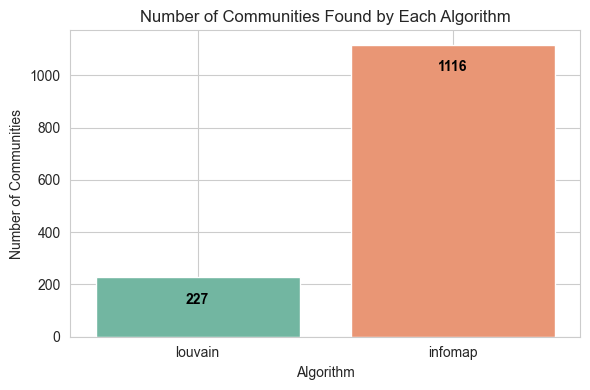

In [113]:
communities = pd.concat([communities_louvain, communities_infomap])

community_counts = communities.groupby('algorithm')['community'].nunique()

print(community_counts)
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x=community_counts.index,
    y=community_counts.values,
    palette="Set2",
    order=['louvain', 'infomap']
)
# Add number labels on top of bars
for i, v in enumerate(community_counts.loc[['louvain', 'infomap']].values):
    ax.text(i, v - max(community_counts.values)*0.1, f"{int(v)}", color='black', ha='center', va='bottom', fontweight='bold')
plt.ylabel('Number of Communities')
plt.xlabel('Algorithm')
plt.title('Number of Communities Found by Each Algorithm')
plt.tight_layout()
plt.grid(True)
plt.savefig(PATH_PLOTS / 'community_counts.png', dpi=300)
plt.show()

In [114]:
## Distribution of the Community Sizes
communities_alg = communities.groupby(['algorithm', 'community'])
community_sizes = communities_alg.size().reset_index(name='size').sort_values('size', ascending=False)
print(community_sizes.shape)
community_sizes.head()

(1343, 3)


,algorithm,community,size
1116,louvain,0,5865
1118,louvain,2,3377
1117,louvain,1,2857
9,infomap,10,2335
1122,louvain,6,2326


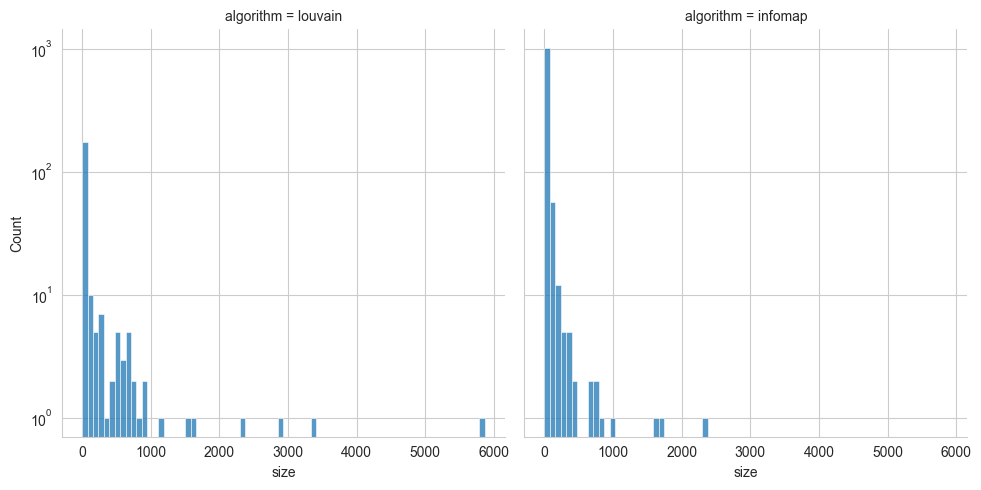

In [118]:
# ax.grid(True)

sns.displot(
    x='size',
    data=community_sizes,
    col='algorithm',
)
ax = plt.gca()
ax.set_yscale('log')
ax.grid(True)
plt.savefig(PATH_PLOTS / 'community_size_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## Tables

In [119]:
evaluation_df = pd.read_csv(PATH_INFOMAP / 'infomap_evaluation.csv')
evaluation_df

,algorithm,graph_variant,num_transactions,num_phishing_transactions,num_non_phishing_transactions,num_communities,global_phishing_node_rate,max_phishing_enrichment,median_phishing_enrichment,communities_with_phishing_nodes,phishing_transaction_internality,non_phishing_transaction_internality,all_transaction_internality,top_1pct_phishing_node_coverage,top_5pct_phishing_node_coverage,top_10pct_phishing_node_coverage
0,infomap,directed_count,84557,5448,79109,1116,0.034554,28.940299,0.0,197,0.848385,0.774311,0.779084,0.684328,0.849254,0.935821


In [120]:
# Display summary statistics in the specified format from evaluation_df

row = evaluation_df.iloc[0]

def pct(x, decimals=2):
    return f"{x*100:.{decimals}f}\\%"

def integer_with_commas(x):
    return f"{int(x):,}"

summary_lines = [
    f"Transactions & {integer_with_commas(row['num_transactions'])} \\\\",
    f"Phishing-labelled transactions & {integer_with_commas(row['num_phishing_transactions'])} \\\\",
    f"Non-phishing-labelled transactions & {integer_with_commas(row['num_non_phishing_transactions'])} \\\\",
    f"Global phishing-incident address rate & {pct(row['global_phishing_node_rate'], 2)} \\\\",
    f"Communities with phishing-incident addresses & {integer_with_commas(row['communities_with_phishing_nodes'])} / {integer_with_commas(row['num_communities'])} \\\\",
    f"Phishing transaction internality & {pct(row['phishing_transaction_internality'], 2)} \\\\",
    f"Non-phishing transaction internality & {pct(row['non_phishing_transaction_internality'], 2)} \\\\",
    f"All transaction internality & {pct(row['all_transaction_internality'], 2)} \\\\",
    f"Top 1\\% phishing-address coverage & {pct(row['top_1pct_phishing_node_coverage'], 2)} \\\\",
    f"Top 5\\% phishing-address coverage & {pct(row['top_5pct_phishing_node_coverage'], 2)} \\\\",
    f"Top 10\\% phishing-address coverage & {pct(row['top_10pct_phishing_node_coverage'], 2)} \\\\",
    f"Maximum phishing enrichment & {row['max_phishing_enrichment']:.2f} \\\\",
    f"Median phishing enrichment & {row['median_phishing_enrichment']:.2f} \\\\"
]

for line in summary_lines:
    print(line)

Transactions & 84,557 \\
Phishing-labelled transactions & 5,448 \\
Non-phishing-labelled transactions & 79,109 \\
Global phishing-incident address rate & 3.46\% \\
Communities with phishing-incident addresses & 197 / 1,116 \\
Phishing transaction internality & 84.84\% \\
Non-phishing transaction internality & 77.43\% \\
All transaction internality & 77.91\% \\
Top 1\% phishing-address coverage & 68.43\% \\
Top 5\% phishing-address coverage & 84.93\% \\
Top 10\% phishing-address coverage & 93.58\% \\
Maximum phishing enrichment & 28.94 \\
Median phishing enrichment & 0.00 \\


In [130]:
community_counts
# data = []
for alg, community in zip(community_counts.index, community_counts.values):
    # print(alg, community)
    for i in [1, 0.1, 0.05, 0.01]:
        print(f"{alg} & ${int(i*100)}\\%$ & ${int(community * i)}$ \\\\ ")


infomap & $100\%$ & $1116$ \\ 
infomap & $10\%$ & $111$ \\ 
infomap & $5\%$ & $55$ \\ 
infomap & $1\%$ & $11$ \\ 
louvain & $100\%$ & $227$ \\ 
louvain & $10\%$ & $22$ \\ 
louvain & $5\%$ & $11$ \\ 
louvain & $1\%$ & $2$ \\ 


In [133]:
# top communities

df_top_communities = pd.read_csv(PATH_INFOMAP / 'infomap_top_communities.csv')
df_top_communities.head(10)

,community,community_size,phishing_incident_nodes,total_phishing_incident_transactions,total_incident_transactions,phishing_node_rate,phishing_enrichment
0,1,1617,396,805,11109,0.244898,7.087420
1,98,55,13,33,264,0.236364,6.840434
2,106,51,12,78,300,0.235294,6.809482
3,9,115,24,65,1829,0.208696,6.039714
4,55,89,17,51,820,0.191011,5.527922
5,58,52,9,24,330,0.173077,5.008898
6,11,344,44,116,1873,0.127907,3.701666
7,10,2335,256,676,5739,0.109636,3.172898
8,18,476,49,111,2494,0.102941,2.979148
9,32,80,8,14,514,0.100000,2.894030


In [134]:
import sys

# Print LaTeX table for top communities, including the community column
print(r"\begin{table}[h]")
print()
print(r"\centering")
print(r"\begin{tabular}{rrrrr}")
print(r"\hline")
print(r"Community & Size & Phishing nodes & Phishing rate & Enrichment \\")
print(r"\hline")

for _, row in df_top_communities.head(10).iterrows():
    community = int(row['community'])
    size = f"{int(row['community_size']):,}"
    nodes = f"{int(row['phishing_incident_nodes']):,}"
    rate = f"{row['phishing_node_rate'] * 100:.2f}\\%"
    enrich = f"{row['phishing_enrichment']:.2f}"
    print(f"{community} & {size} & {nodes} & {rate} & {enrich} \\\\")
    
print(r"\hline")
print(r"\end{tabular}")
print(r"\caption{Phishing-enriched Infomap communities with at least 50 nodes.}")
print(r"\label{tab:infomap-large-enriched}")
print(r"\end{table}")

\begin{table}[h]

\centering
\begin{tabular}{rrrrr}
\hline
Community & Size & Phishing nodes & Phishing rate & Enrichment \\
\hline
1 & 1,617 & 396 & 24.49\% & 7.09 \\
98 & 55 & 13 & 23.64\% & 6.84 \\
106 & 51 & 12 & 23.53\% & 6.81 \\
9 & 115 & 24 & 20.87\% & 6.04 \\
55 & 89 & 17 & 19.10\% & 5.53 \\
58 & 52 & 9 & 17.31\% & 5.01 \\
11 & 344 & 44 & 12.79\% & 3.70 \\
10 & 2,335 & 256 & 10.96\% & 3.17 \\
18 & 476 & 49 & 10.29\% & 2.98 \\
32 & 80 & 8 & 10.00\% & 2.89 \\
\hline
\end{tabular}
\caption{Phishing-enriched Infomap communities with at least 50 nodes.}
\label{tab:infomap-large-enriched}
\end{table}


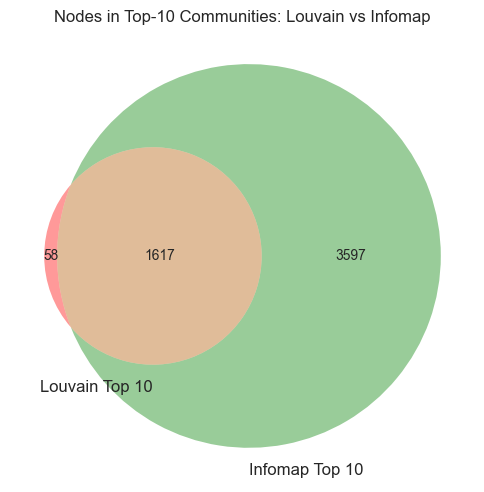

In [138]:
# --- 1. Gather all nodes for each of the top-10 communities for the infomap and louvain algorithm ---

from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# Load louvain top communities
# PATH_LOUVAIN = PATH_OUTPUT / "algorithms" / "louvain"
df_louvain_top = pd.read_csv(PATH_LOUVAIN / "louvain_top_communities.csv")
top10_infomap_comm_ids = set(df_top_communities.head(10)["community"].astype(int))
top10_louvain_comm_ids = set(df_louvain_top.head(10)["community"].astype(int))

# Load all assignments
df_infomap_comm = pd.read_csv(PATH_INFOMAP / "infomap_communities.csv")  # columns: node,algorithm,graph_variant,community
df_louvain_comm = pd.read_csv(PATH_LOUVAIN / "louvain_communities.csv")  # columns: node,algorithm,graph_variant,community

# Get nodes in top-10 communities for each algorithm
nodes_infomap_top10 = set(
    df_infomap_comm[df_infomap_comm["community"].isin(top10_infomap_comm_ids)]["node"]
)
nodes_louvain_top10 = set(
    df_louvain_comm[df_louvain_comm["community"].isin(top10_louvain_comm_ids)]["node"]
)

# --- 2. Compute a Venn diagram of which nodes are included in the big set w.r.t. each algorithm ---

plt.figure(figsize=(6, 6))
venn2([nodes_louvain_top10, nodes_infomap_top10],
      set_labels=("Louvain Top 10", "Infomap Top 10"))
plt.title("Nodes in Top-10 Communities: Louvain vs Infomap")
plt.savefig(PATH_PLOTS / 'venn_diagram.png', dpi=300)
plt.show()

## Syflow

### Infomap

In [162]:
# For each community found by infomap, compute:
#   phishing_node_rate = (# phishing nodes in community) / (community size)
#   phishing_enrichment = (phishing_node_rate) / (global phishing node rate)

# Load the full list of infomap community assignments and the phishing labels
df_infomap_comm = pd.read_csv(PATH_INFOMAP / "infomap_communities.csv")  # columns: node,algorithm,graph_variant,community

# Assume a DataFrame or Series with phishing labels indexed by node address
# e.g. "phishing_labels": index=node, value=True/False whether node is a phishing node
# Try to find or load that
PHISHING_LABELS_CSV = PATH_INFOMAP / '..' / '..' / 'misc' / "node_labels.csv"
phishing_labels = pd.read_csv(PHISHING_LABELS_CSV, index_col="node")["is_phishing"].astype(bool)

df_infomap_comm["is_phishing"] = df_infomap_comm["node"].map(phishing_labels).fillna(False)

# Compute global phishing node rate (all nodes across all comms)
global_phishing_node_rate = df_infomap_comm["is_phishing"].mean()

# For each community: community_size, phishing_incident_nodes, phishing_node_rate, phishing_enrichment
df_infomap_comm_stats = (
    df_infomap_comm.groupby("community")
    .agg(
        community_size=("node", "count"),
        phishing_incident_nodes=("is_phishing", "sum"),
    )
    .reset_index()
)
df_infomap_comm_stats["phishing_node_rate"] = (
    df_infomap_comm_stats["phishing_incident_nodes"] / df_infomap_comm_stats["community_size"]
)
df_infomap_comm_stats["phishing_enrichment"] = (
    df_infomap_comm_stats["phishing_node_rate"] / global_phishing_node_rate
)

# Optionally sort by enrichment or size
df_infomap_comm_stats = df_infomap_comm_stats.sort_values("phishing_enrichment", ascending=False)

# Inspect the top rows
print(df_infomap_comm_stats.head(10))
df_infomap_comm_stats.shape

     community  community_size  phishing_incident_nodes  phishing_node_rate  \
320        321               1                        1                 1.0   
337        338               1                        1                 1.0   
413        414               1                        1                 1.0   
151        152               1                        1                 1.0   
407        408               1                        1                 1.0   
385        386               1                        1                 1.0   
383        384               1                        1                 1.0   
379        380               1                        1                 1.0   
878        879               1                        1                 1.0   
365        366               1                        1                 1.0   

     phishing_enrichment  
320            28.940299  
337            28.940299  
413            28.940299  
151            28.9402

(1116, 5)

In [168]:
df_syflow_membership

,community,subgroup_id,in_subgroup
0,1,1,True
1,2,1,False
2,3,1,False
3,4,1,False
4,5,1,False
...,...,...,...
3343,1112,3,False
3344,1113,3,False
3345,1114,3,False
3346,1115,3,False


In [187]:
df_infomap_comm_stats['subgroup_1']

320     False
337     False
413     False
151     False
407     False
        ...  
470     False
472     False
473     False
474     False
1115    False
Name: subgroup_1, Length: 1116, dtype: bool

In [207]:
# df_syflow_membership[df_syflow_membership['subgroup_id'] == 3]['in_subgroup']
df_infomap_comm_stats['subgroup_2']

320     NaN
337     NaN
413     NaN
151     NaN
407     NaN
       ... 
470     NaN
472     NaN
473     NaN
474     NaN
1115    NaN
Name: subgroup_2, Length: 1116, dtype: object

1 76
2 0
3 64


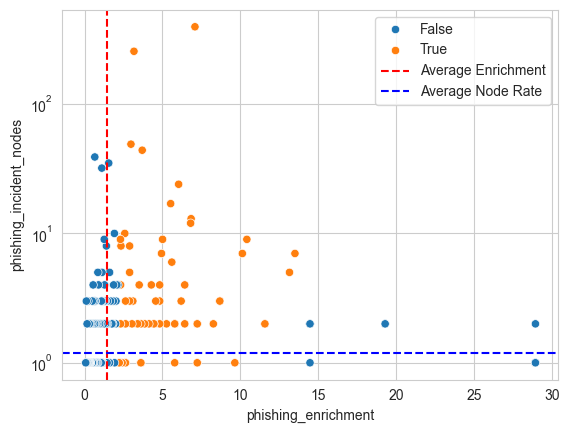

In [223]:
# load syflow
syflow_membership_path = Path("../subgroup_descriptions/infomap_syflow/infomap_syflow_membership.csv")

df_syflow_membership = pd.read_csv(syflow_membership_path)
# df_syflow_membership.head(10)

avg_phishing_enrichment = df_infomap_comm_stats['phishing_enrichment'].mean()
avg_phishing_node_rate = df_infomap_comm_stats['phishing_incident_nodes'].mean()

# The problem is that df_infomap_comm_stats and df_syflow_membership may have mismatched indices.
# We should create a "community"->"in_subgroup" mapping for each subgroup and assign using the "community" column as the key.

# Ensure that the index of df_infomap_comm_stats is "community" for easy assignment
if "community" not in df_infomap_comm_stats.index.names:
    df_infomap_comm_stats = df_infomap_comm_stats.set_index("community")

for subgroup_id in df_syflow_membership['subgroup_id'].unique():
    # Build a mapping from community to subgroup membership (True/False)
    membership_map = df_syflow_membership[df_syflow_membership['subgroup_id'] == subgroup_id].set_index("community")["in_subgroup"]
    # Reindex over comm_stats, fill missing as False (or as NaN if preferred)
    # Here, fillna(False) means communities not present in membership file are not in subgroup
    df_infomap_comm_stats[f'subgroup_{subgroup_id}'] = df_infomap_comm_stats.index.map(membership_map).fillna(False)
    print(subgroup_id, df_infomap_comm_stats[f'subgroup_{subgroup_id}'].sum())

df_infomap_comm_stats = df_infomap_comm_stats.reset_index()  # Reset index to original form if desired

sns.scatterplot(
    data=df_infomap_comm_stats,
    x='phishing_enrichment',
    y='phishing_incident_nodes',
    # hue='community_size'
    hue='subgroup_3'
)
ax = plt.gca()
# ax.set_xscale('log')
ax.set_yscale('log')

ax.axvline(avg_phishing_enrichment, color='red', linestyle='--', label='Average Enrichment')
ax.axhline(avg_phishing_node_rate, color='blue', linestyle='--', label='Average Node Rate')

ax.legend()
plt.show()




In [224]:

# # --- 1. Load Syflow subgroup membership and summary ---

# # Read membership CSV
# syflow_membership_path = Path("../subgroup_descriptions/infomap_syflow/infomap_syflow_membership.csv")
# # syflow_membership_path = Path("../subgroup_descriptions/louvain_syflow/louvain_syflow_membership.csv")
# # Try to read with and without a header to handle both cases robustly
# try:
#     # Attempt with the expected headerless format
#     df_syflow_membership = pd.read_csv(
#         syflow_membership_path,
#         header=None,
#         names=["community", "subgroup_id", "phishing_incident"]
#     )
#     # If the first row is a header, it may result in conversion error below
#     # (community column would contain 'community' string)
#     # So, check and drop that row if needed
#     if df_syflow_membership["community"].iloc[0] == "community":
#         df_syflow_membership = df_syflow_membership.iloc[1:].reset_index(drop=True)
# except Exception:
#     # Fallback: try reading with header and generic names
#     df_syflow_membership = pd.read_csv(
#         syflow_membership_path,
#         header=0
#     )

# df_syflow_membership["community"] = df_syflow_membership["community"].astype(int)
# df_syflow_membership["subgroup_id"] = df_syflow_membership["subgroup_id"].astype(int)
# df_syflow_membership["phishing_incident"] = df_syflow_membership["phishing_incident"].map(
#     lambda x: str(x).strip().lower() == "true"
# )
# # Assign node as a string version of index (since node column not in file)
# df_syflow_membership["node"] = df_syflow_membership.index.astype(str)

# # Read summary JSON
# with open("../subgroup_descriptions/infomap_syflow/infomap_syflow_summary.json", "r") as f:
# # with open("../subgroup_descriptions/louvain_syflow/louvain_syflow_summary.json", "r") as f:
#     syflow_summary = json.load(f)

# # --- 2. Compute phishing statistics for each syflow subgroup ---

# # Get total number of nodes and number of phishing nodes per subgroup_id
# phishing_stats = (
#     df_syflow_membership.groupby("subgroup_id")
#     .agg(
#         num_nodes=("node", "count"),
#         num_phishing=("phishing_incident", "sum"),
#     )
#     .reset_index()
# )
# phishing_stats["phishing_rate"] = phishing_stats["num_phishing"] / phishing_stats["num_nodes"]

# # For reference, sort by subgroup size
# phishing_stats = phishing_stats.sort_values(by="num_nodes", ascending=False)

# # --- 3. Print summary table similar to previous LaTeX table ---

# print(r"\begin{table}[ht]")
# print(r"\centering")
# print(r"\begin{tabular}{lccc}")
# print(r"\hline")
# print(r"Subgroup ID & Size & Phishing Nodes & Phishing Rate \\")
# print(r"\hline")

# for _, row in phishing_stats.iterrows():
#     subgroup = int(row['subgroup_id'])
#     size = int(row['num_nodes'])
#     phishing = int(row['num_phishing'])
#     rate = row['phishing_rate']
#     print(f"{subgroup} & {size} & {phishing} & {rate:.2%} \\\\")

# print(r"\hline")
# print(r"\end{tabular}")
# print(r"\caption{Syflow Infomap subgroups: Number of nodes, phishing nodes, and phishing node rate.}")
# print(r"\label{tab:syflow-infomap-phishing}")
# print(r"\end{table}")

# # If desired, show the statistics in a DataFrame too:
# display(phishing_stats)

### Louvain

In [225]:
# For each community found by infomap, compute:
#   phishing_node_rate = (# phishing nodes in community) / (community size)
#   phishing_enrichment = (phishing_node_rate) / (global phishing node rate)

# Load the full list of infomap community assignments and the phishing labels
df_infomap_comm = pd.read_csv(PATH_LOUVAIN / "louvain_communities.csv")  # columns: node,algorithm,graph_variant,community

# Assume a DataFrame or Series with phishing labels indexed by node address
# e.g. "phishing_labels": index=node, value=True/False whether node is a phishing node
# Try to find or load that
PHISHING_LABELS_CSV = PATH_LOUVAIN / '..' / '..' / 'misc' / "node_labels.csv"
phishing_labels = pd.read_csv(PHISHING_LABELS_CSV, index_col="node")["is_phishing"].astype(bool)

df_infomap_comm["is_phishing"] = df_infomap_comm["node"].map(phishing_labels).fillna(False)

# Compute global phishing node rate (all nodes across all comms)
global_phishing_node_rate = df_infomap_comm["is_phishing"].mean()

# For each community: community_size, phishing_incident_nodes, phishing_node_rate, phishing_enrichment
df_infomap_comm_stats = (
    df_infomap_comm.groupby("community")
    .agg(
        community_size=("node", "count"),
        phishing_incident_nodes=("is_phishing", "sum"),
    )
    .reset_index()
)
df_infomap_comm_stats["phishing_node_rate"] = (
    df_infomap_comm_stats["phishing_incident_nodes"] / df_infomap_comm_stats["community_size"]
)
df_infomap_comm_stats["phishing_enrichment"] = (
    df_infomap_comm_stats["phishing_node_rate"] / global_phishing_node_rate
)

# Optionally sort by enrichment or size
df_infomap_comm_stats = df_infomap_comm_stats.sort_values("phishing_enrichment", ascending=False)

# Inspect the top rows
print(df_infomap_comm_stats.head(10))
df_infomap_comm_stats.shape

     community  community_size  phishing_incident_nodes  phishing_node_rate  \
202        202               2                        2            1.000000   
226        226               4                        2            0.500000   
176        176               4                        2            0.500000   
215        215               4                        2            0.500000   
217        217               5                        2            0.400000   
11          11               5                        2            0.400000   
160        160              10                        3            0.300000   
144        144               8                        2            0.250000   
31          31            1623                      396            0.243993   
57          57              10                        2            0.200000   

     phishing_enrichment  
202            28.940299  
226            14.470149  
176            14.470149  
215            14.4701

(227, 5)

1 19
2 142
3 2


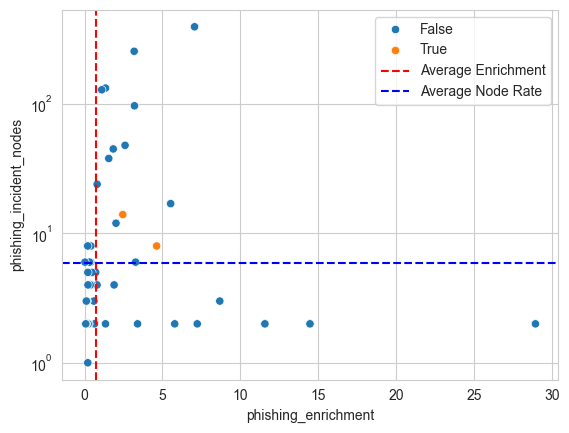

In [229]:
# load syflow
syflow_membership_path = Path("../subgroup_descriptions/louvain_syflow/louvain_syflow_membership.csv")

df_syflow_membership = pd.read_csv(syflow_membership_path)
# df_syflow_membership.head(10)

avg_phishing_enrichment = df_infomap_comm_stats['phishing_enrichment'].mean()
avg_phishing_node_rate = df_infomap_comm_stats['phishing_incident_nodes'].mean()

# The problem is that df_infomap_comm_stats and df_syflow_membership may have mismatched indices.
# We should create a "community"->"in_subgroup" mapping for each subgroup and assign using the "community" column as the key.

# Ensure that the index of df_infomap_comm_stats is "community" for easy assignment
if "community" not in df_infomap_comm_stats.index.names:
    df_infomap_comm_stats = df_infomap_comm_stats.set_index("community")

for subgroup_id in df_syflow_membership['subgroup_id'].unique():
    # Build a mapping from community to subgroup membership (True/False)
    membership_map = df_syflow_membership[df_syflow_membership['subgroup_id'] == subgroup_id].set_index("community")["in_subgroup"]
    # Reindex over comm_stats, fill missing as False (or as NaN if preferred)
    # Here, fillna(False) means communities not present in membership file are not in subgroup
    df_infomap_comm_stats[f'subgroup_{subgroup_id}'] = df_infomap_comm_stats.index.map(membership_map).fillna(False)
    print(subgroup_id, df_infomap_comm_stats[f'subgroup_{subgroup_id}'].sum())

df_infomap_comm_stats = df_infomap_comm_stats.reset_index()  # Reset index to original form if desired

sns.scatterplot(
    data=df_infomap_comm_stats,
    x='phishing_enrichment',
    y='phishing_incident_nodes',
    # hue='community_size'
    hue='subgroup_3'
)
ax = plt.gca()
# ax.set_xscale('log')
ax.set_yscale('log')

ax.axvline(avg_phishing_enrichment, color='red', linestyle='--', label='Average Enrichment')
ax.axhline(avg_phishing_node_rate, color='blue', linestyle='--', label='Average Node Rate')

ax.legend()
plt.show()


